In [39]:
import pandas as pd
import numpy as np

df=pd.read_csv('..\data\Steel_industry_data.csv')
df.head()

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\owner\AppData\Local\Temp\ipykernel_7412\3215317734.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df=pd.read_csv('..\data\Steel_industry_data.csv')


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [40]:
zero_rows=df[df['Usage_kWh']==0]

print(len(zero_rows))

print(zero_rows['WeekStatus'].value_counts())
print(zero_rows['Load_Type'].value_counts())

df['date']=pd.to_datetime(df['date'],dayfirst=True)
df=df.set_index('date')
df[df['Usage_kWh']==0]

df=df.sort_index()
df.loc['2018-11-06 23:45':'2018-11-8']

cols=['Usage_kWh','Lagging_Current_Reactive.Power_kVarh','Lagging_Current_Power_Factor','Leading_Current_Power_Factor']
df[cols]=df[cols].replace(0,np.nan).interpolate(method='linear')

df2=df


1
WeekStatus
Weekday    1
Name: count, dtype: int64
Load_Type
Light_Load    1
Name: count, dtype: int64


<Axes: xlabel='date'>

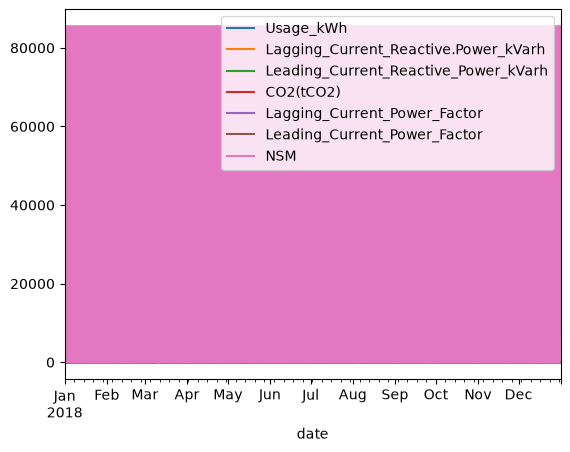

In [42]:
df2.plot()